<a href="https://colab.research.google.com/github/VikaSvyat/DI_Bootcamp/blob/main/Week11/Exercises_XP_DL_Neural_Networks_polynomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training Deep Neural Networks Exercises XP

https://octopus.developers.institute/courses/collection/124/course/722/section/1965/chapter/4394#


# Exercises XP: Guided Student Notebook

This guided notebook follows the **exact exercise on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts to support intuition and transfer to other AI topics.



## Reference from the exercise

**What you will learn**  
- The differences between traditional machine learning and deep learning.
- The structure and working of artificial neural networks. How to generate, visualize, and analyze datasets with noise.
- Techniques for fitting polynomial regression models and understanding overfitting.
- The importance of cross-validation in model selection.

**What you will create**  
- A comparative table of traditional machine learning vs deep learning.
- A simple ANN diagram with labeled components.
- A noisy dataset visualized with a scatter plot.
- Polynomial regression models of varying degrees.
- A cross-validation analysis to select an optimal polynomial degree.


## 🌟 Exercise 1: Deep Learning vs Traditional Machine Learning

**As stated in the exercise**  
Objective. Understand the differences between traditional machine learning and deep learning.  
Instructions. Create a table comparing Feature Engineering, Data Processing, Scalability, Pattern Discovery, and Computational Requirements. Identify one real world problem where traditional ML is better, and one where deep learning is better. Write a short paragraph explaining why deep learning has an advantage in unstructured data processing.

**Guidance**  
Use a markdown table for the comparison, keep wording concise and concrete, then write two short examples and one paragraph in full sentences.

**To-Do:** Complete the comparison table below by filling in each cell with your own wording.


| Aspect | Traditional ML | Deep Learning |
|:--|:--|:--|
| Feature Engineering | Hands-on selection of features | Automatic feature extraction |
| Data Processing | Better with table, structured data | Good for unstructured data (image, audio, text) |
| Scalability | Don't perform better when data set increase| Perform better on bigger data set |
| Pattern Discovery | Can find simple and linear dependencies | Can find copmpexive and non-linear dependencies |
| Computational Requirements | Low (enough CPU) | High (required GPU/TPU) |

**To-Do:** Give one real world problem better suited to traditional ML and one better suited to deep learning. Explain your choices in 2–3 sentences.

---
**ML:**

Credit scoring (borrower risk assessment):

- Data is structured (age, income, history)

- Models like Logistic Regression or Random Forest work well

- Fast, interpretable, and resource-efficient

**DL:**

Image recognition (e.g., MNIST or face recognition)

- Data — pixels (unstructured)

- Complex patterns required

- CNN is significantly better than classical methods



**To-Do:** Write a paragraph of 3–5 sentences explaining why deep learning has an advantage in unstructured data processing, using precise terms such as representation learning and hierarchical features.

---
Deep learning has a significant advantage in unstructured data processing due to its ability to perform representation learning, automatically extracting meaningful features directly from raw data. Deep neural networks learn hierarchical features, where lower layers capture simple patterns (such as edges or basic sounds) and deeper layers combine them into more complex and abstract representations. This layered structure allows models to capture highly nonlinear relationships that are difficult to specify explicitly. As a result, deep learning is particularly effective for tasks involving images, text, and audio, where the underlying structure is complex and not easily defined by hand.

## 🌟 Exercise 2: Artificial Neural Networks (ANNs)

**As stated in the exercise**  
Objective. Identify and understand the key components of an ANN.  
Instructions. Draw or use a diagram tool to create an ANN with an input layer of 3 neurons, one hidden layer of 4 neurons, and an output layer of 2 neurons. Label neurons, weights, biases, activation function, and layers. Write a short description of how information flows through the network.

**Guidance**  
A clear schematic is preferred. Ensure every requested label appears exactly once and is readable.

```
Input Layer      Hidden Layer      Output Layer

[ x1 ]           [ h1 ]            [ y1 ]
[ x2 ]  ------>  [ h2 ]  ------>   [ y2 ]
[ x3 ]           [ h3 ]
                 [ h4 ]

Where:
x1, x2, x3  = input neurons  
h1–h4       = hidden neurons  
y1, y2      = output neurons  

Each connection has:
- weight (w)
- bias (b added at each neuron)
- activation function f(·)

Each neuron: z = wx + b → activation f(z)

**To-Do:** Provide a 3–5 sentence description of forward propagation in your diagram. Refer explicitly to inputs, weighted sums, biases, activation, and outputs.


---


Information flows through the network from the input layer to the output layer. Each input is multiplied by weights, summed together with a bias, and passed through an activation function in the hidden layer. The hidden layer transforms the data into a new representation, which is then passed to the output layer. The output layer applies the same process to produce the final predictions.

**Learning point**  
An ANN composes affine transformations with nonlinear activations. The affine part mixes features through weights and biases. The nonlinearity enables modeling of complex decision boundaries.


## 🌟 Exercise 3: Creating the Dataset and Visualizing the Data

**As stated in the exercise**  
Objective. Generate a dataset with noise and visualize it.  
Instructions. Import numpy, matplotlib.pyplot, and mean_squared_error from sklearn.metrics. Create 20 points using \(y = -x^2\) with Gaussian noise \(\mathcal{N}(0, 0.05)\). Plot the points with a scatter plot. Split into a training set with the first 12 points and a test set with the last 8 points.


In [1]:
# PREFILLED: just execute
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

np.random.seed(0)
x = np.arange(-1, 1, 0.1)  # 20 points from -1 to <1 step 0.1
print("x shape:", x.shape)

x shape: (20,)


In [2]:
# To-Do: generate y with noise using np.random.normal()

y = 2 * x + np.random.normal(0, 0.1, size=x.shape)
print("y shape:", y.shape)

y shape: (20,)


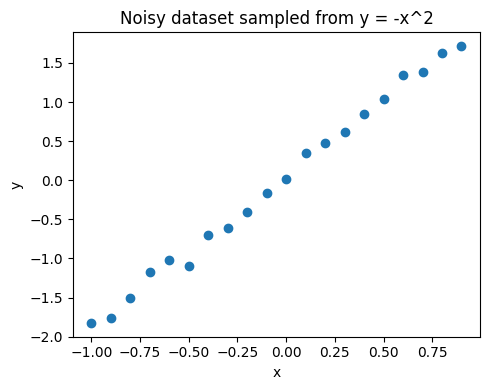

In [3]:
# PREFILLED: just execute (scatter plot of the dataset)
plt.figure(figsize=(5,4))
plt.scatter(x, y)
plt.title("Noisy dataset sampled from y = -x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [4]:
# To-Do: split into train (first 12 points) and test (last 8 points)
x_train, y_train = x[:12], y[:12]
x_test,  y_test  = x[12:], y[12:]

print("train sizes:", x_train.shape, y_train.shape,
      "test sizes:", x_test.shape, y_test.shape)

train sizes: (12,) (12,) test sizes: (8,) (8,)


**Learning point**  
Visualizing noisy data helps separate signal from noise. Splitting into train and test allows you to detect when a model overfits noise instead of learning the underlying pattern.


## 🌟 Exercise 4: Fitting Polynomial Models of Different Degrees

**As stated in the exercise**  
Objective: Fit polynomial models of varying degrees and observe overfitting.  

Instructions: Define `polynomial_fit(degree)` that returns the fitted polynomial coefficients from training data. Define `plot_polyfit(degree)` that draws the training set, the test set, and the fitted polynomial curve. Visualize fits for degrees 1, 7, and 11. Observe behavior on training and test sets as degree increases.


In [9]:
# To-Do: implement polynomial_fit
# Hints: use np.polyfit() to get coefficients, and np.poly1d for a callable polynomial
#def polynomial_fit(degree: int):
#     # To-Do: return np.poly1d(coeffs)
#     raise NotImplementedError
def polynomial_fit(degree):
    coeffs = np.polyfit(x_train, y_train, degree)
    return coeffs

In [10]:
# To-Do: implement plot_polyfit
import numpy as np
import matplotlib.pyplot as plt
# def plot_polyfit(degree: int):
#     # 1) fit
#     # 2) create a dense linspace over x range
#     # 3) evaluate fitted polynomial
#     # 4) scatter train and test, and plot curve
#     # 5) display
#     pass

def plot_polyfit(degree):
    coeffs = polynomial_fit(degree)
    poly = np.poly1d(coeffs)

    x_plot = np.linspace(-1, 1, 100)
    y_plot = poly(x_plot)

    plt.figure()

    # train
    plt.scatter(x_train, y_train, label="Train")

    # test
    plt.scatter(x_test, y_test, label="Test")

    # model
    plt.plot(x_plot, y_plot, label=f"Degree {degree}")

    plt.legend()
    plt.title(f"Polynomial Fit (degree={degree})")
    plt.show()

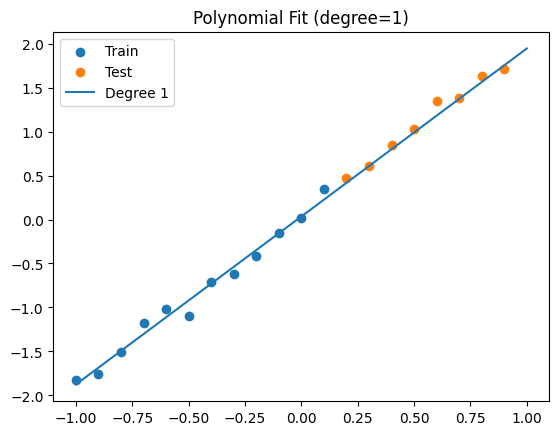

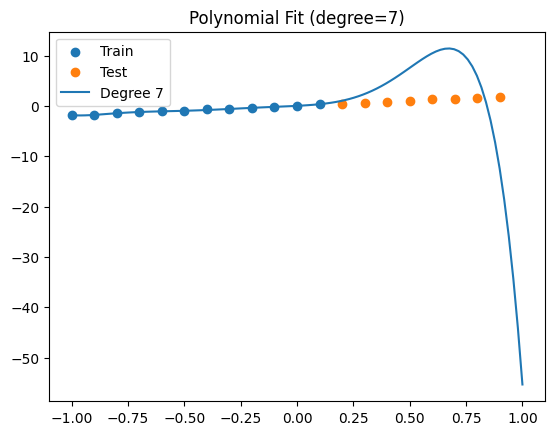

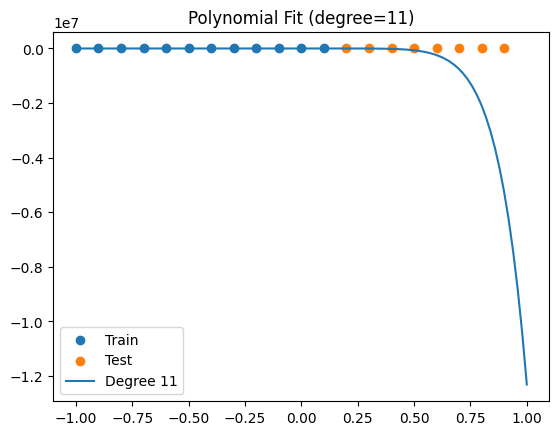

In [11]:
# To-Do: visualize degrees 1, 7, and 11
plot_polyfit(1)
plot_polyfit(7)
plot_polyfit(11)

**Learning point**  
Higher degree polynomials can perfectly fit training data yet fail to generalize. This is overfitting. You should always check test error, not just training error.

![image.png](https://github.com/user-attachments/assets/cdfb495c-066a-4efb-a361-f4b9d4ade35c)

## 🌟 Exercise 5: Cross-Validation to Find the Optimal Degree

**As stated in the exercise**  
Objective: Use cross-validation to determine the best polynomial degree.  

Instructions: Loop degrees from 1 to 11. For each degree, compute the RMSE on the training and test sets. Store results in a list. Plot RMSE vs degree with a logarithmic y axis. Identify the degree minimizing test RMSE and confirm it matches the true model \(y=-x^2\).


In [19]:
# To-Do: compute RMSE per degree for train and test
# def rmse(y_true, y_pred): ...
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))
# degrees = range(1, 12)
# rows = []  # each row: (degree, rmse_train, rmse_test)
# for d in degrees:
#     # fit on train
#     # evaluate on train and test
#     # append to rows
#     pass
# rows[:3]  # peek

degrees = range(1, 12)
rows = []  # each row: (degree, rmse_train, rmse_test)

for d in degrees:
    # fit model
    coeffs = np.polyfit(x_train, y_train, d)
    poly = np.poly1d(coeffs)

    # predictions
    y_train_pred = poly(x_train)
    y_test_pred = poly(x_test)

    # errors
    train_rmse = rmse(y_train, y_train_pred)
    test_rmse = rmse(y_test, y_test_pred)

    rows.append((d, train_rmse, test_rmse))
    print(rows[:3])

[(1, np.float64(0.08697066872962769), np.float64(0.07254035716278148))]
[(1, np.float64(0.08697066872962769), np.float64(0.07254035716278148)), (2, np.float64(0.0822918098930197), np.float64(0.25156128564772934))]
[(1, np.float64(0.08697066872962769), np.float64(0.07254035716278148)), (2, np.float64(0.0822918098930197), np.float64(0.25156128564772934)), (3, np.float64(0.07467384462217193), np.float64(1.539303986160147))]
[(1, np.float64(0.08697066872962769), np.float64(0.07254035716278148)), (2, np.float64(0.0822918098930197), np.float64(0.25156128564772934)), (3, np.float64(0.07467384462217193), np.float64(1.539303986160147))]
[(1, np.float64(0.08697066872962769), np.float64(0.07254035716278148)), (2, np.float64(0.0822918098930197), np.float64(0.25156128564772934)), (3, np.float64(0.07467384462217193), np.float64(1.539303986160147))]
[(1, np.float64(0.08697066872962769), np.float64(0.07254035716278148)), (2, np.float64(0.0822918098930197), np.float64(0.25156128564772934)), (3, np.floa

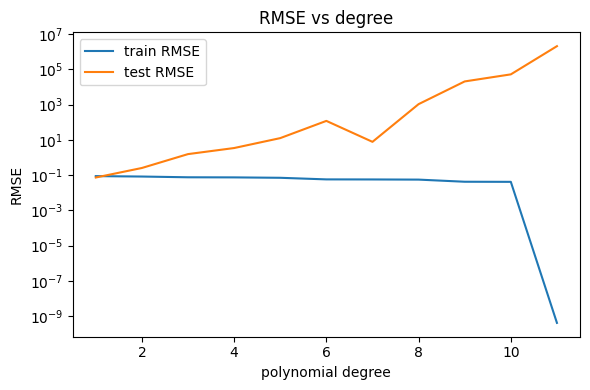

In [17]:
# Pre-filled: plotting RMSE curves (one figure, two curves)
degs = [r[0] for r in rows]
rmse_tr = [r[1] for r in rows]
rmse_te = [r[2] for r in rows]
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(degs, rmse_tr, label="train RMSE")
plt.plot(degs, rmse_te, label="test RMSE")
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.ylabel("RMSE")
plt.title("RMSE vs degree")
plt.legend()
plt.tight_layout()
plt.show()


**To-Do:** Report the degree with the minimum test RMSE and explain in 2–3 sentences how this connects to the true model \(y=-x^2\) and the bias–variance trade off.


---
degree with the minimum test RMSE = 1 (not 2)
That can be because of a small data set, and since the data is randomly generated, the specific test set might have points that a linear approximation accidentally predicts better.
